# Predicción de Informalidad Laboral en Colombia
## Clasificación con Random Forest (Bosques Aleatorios)

En este *Notebook* abordaremos el problema de la **informalidad laboral** desde una perspectiva de Machine Learning. 
La informalidad no solo representa una pérdida de ingresos para el Estado, sino que precariza profundamente las condiciones de vida del trabajador (como el "castigo salarial" que observamos en nuestros modelos econométricos previos).

### Objetivo
Construiremos un modelo robusto de clasificación utilizando el algoritmo **Random Forest** para predecir si un trabajador caerá en la informalidad (variable binaria `informal = 1` o `0`).
Se optó por utilizar Bosques Aleatorios porque:
1. Captura excepcionalmente bien relaciones **no lineales** entre las características demográficas (ej. cómo la edad y la educación interactúan).
2. Es sumamente resistente a valores atípicos (outliers) en los ingresos o en otras métricas.
3. Al utilizar múltiples árboles de decisión (Ensemble), generaliza mejor y reduce el sobreajuste frente a un árbol tradicional.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Asegurar que exista la carpeta Resultados
os.makedirs("../Resultados", exist_ok=True)

# Configuración estética profesional para los gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Módulos de Scikit-Learn para el Modelado
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, RocCurveDisplay


Error in callback <bound method PositronShell._handle_post_run_cell of <positron.positron_ipkernel.PositronShell object at 0x0000021A2491F770>> (for post_run_cell), with arguments args (<ExecutionResult object at 21a5869b450, execution_count=9 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 21a58699c50, raw_cell="import pandas as pd
import numpy as np
import matp.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/c%3A/Users/diego/Documents/GEIH-Desigualdad-Salarial/scripts/5_modeloIA.ipynb#W1sZmlsZQ%3D%3D> result=None>,),kwargs {}:


KeyboardInterrupt: 

## 1. Carga y Limpieza de Datos
Cargamos la base de datos pre-procesada de la Gran Encuesta Integrada de Hogares (GEIH). Un paso crítico en Machine Learning es eliminar estrictamente cualquier fila que contenga valores nulos (`NaN`) en nuestras variables objetivo, ya que los modelos de `scikit-learn` requieren conjuntos de datos matemáticamente completos.


In [ ]:
# Cargar los datos (ruta relativa a la carpeta scripts)
try:
    df = pd.read_csv("../Data/Procesed-based/cleaned_base.csv")
    print("Base de datos cargada correctamente.")
except FileNotFoundError:
    print("Error: Revisa que el archivo exista en la ruta especificada (../Data/Procesed-based/cleaned_base.csv).")

# Lista explícita de variables que usaremos para entrenar el modelo
variables_modelo = ['informal', 'sexo', 'edad', 'nivel_educativo', 'rama_actividad', 'Tiempo_empresa']

# Eliminar registros con nulos (fundamental para que el .fit() no arroje ValueError: Input y contains NaN)
filas_iniciales = len(df)
df = df.dropna(subset=variables_modelo)
filas_finales = len(df)

print(f"Total de registros originales: {filas_iniciales}")
print(f"Total de registros utilizables tras limpieza de nulos: {filas_finales}")


Base de datos cargada correctamente.
Total de registros originales: 188428
Total de registros utilizables tras limpieza de nulos: 185809


## 2. Preprocesamiento de Variables (X e y)
Los algoritmos de Machine Learning operan estrictamente con tensores numéricos. Para variables categóricas (como la "rama de actividad" o el "nivel educativo"), necesitamos transformar texto/categorías en números sin inducir un orden numérico falso.
Aplicamos **One-Hot Encoding** (Variables Dummy) para convertir cada categoría en una columna de ceros (0) y unos (1).


In [ ]:
# Definición de la Variable Objetivo (Y) y las Variables Predictoras (X)
y = df['informal']
X = df[['sexo', 'edad', 'nivel_educativo', 'rama_actividad', 'Tiempo_empresa']]

# Conversión a variables Dummy
# El parámetro drop_first=True evita la "trampa de la multicolinealidad" eliminando una categoría de referencia
X = pd.get_dummies(X, columns=['nivel_educativo', 'rama_actividad'], drop_first=True)


## 3. División del Conjunto de Datos (Train / Test)
Para medir correctamente la capacidad del modelo de predecir casos nuevos en el mundo real, dividimos la base: un 80% para **Entrenamiento** (aprender patrones) y un 20% para **Prueba** (evaluación a ciegas).
El parámetro `stratify=y` asegura que la proporción real de formales/informales se mantenga idéntica en ambos grupos.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,      
    random_state=42,     
    stratify=y           
)

print(f"Dimensiones de Entrenamiento (Train): {X_train.shape[0]} registros.")
print(f"Dimensiones de Prueba (Test): {X_test.shape[0]} registros.")


Dimensiones de Entrenamiento (Train): 148647 registros.
Dimensiones de Prueba (Test): 37162 registros.


## 4. Construcción del Bosque Aleatorio: Tuning Manual de Hiperparámetros
En vez de utilizar la configuración por defecto, estableceremos de forma manual los hiperparámetros fundamentales para asegurar un aprendizaje controlado, evitar el *overfitting* (memorización) y asegurar un rendimiento profesional:

*   **`n_estimators=200`**: Crearemos un "bosque" de 200 árboles de decisión. A mayor cantidad de árboles, mayor robustez, aunque con un coste computacional mayor.
*   **`criterion='gini'`**: Utilizamos la Impureza de Gini para medir la calidad de las divisiones en los nodos. El modelo priorizará los cortes que separen lo mejor posible la formalidad de la informalidad.
*   **`max_depth=15`**: Limitamos el crecimiento de cada árbol a 15 niveles de profundidad. Si el árbol es demasiado profundo, memorizará ruido específico de la GEIH (overfitting).
*   **`min_samples_split=20`**: Exigimos que un nodo tenga al menos 20 registros antes de considerar dividirlo en dos ramas más. 
*   **`min_samples_leaf=10`**: Cada nodo final (veredicto) deberá tener un soporte mínimo de 10 casos reales. Esto evita ramificaciones extremas para predecir casos atípicos o marginales.
*   **`class_weight='balanced'`**: Compensa matemáticamente el desequilibrio natural si hay más informales que formales (o viceversa) en Colombia, dándole mayor peso a los errores de la clase minoritaria.
*   **`n_jobs=-1`**: Paralelización máxima, aprovechando todos los núcleos del procesador.


In [ ]:
# Instanciación del modelo con Tuning Manual
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  
)

# Entrenar el modelo
print("Iniciando entrenamiento del Random Forest... (Por favor espera)")
modelo_rf.fit(X_train, y_train)
print("¡Entrenamiento del modelo completado exitosamente!")


Iniciando entrenamiento del Random Forest... (Por favor espera)
¡Entrenamiento del modelo completado exitosamente!


## 5. Predicción y Evaluación de Resultados
Evaluaremos al modelo utilizando métricas de clasificación en el conjunto de datos de Prueba (`X_test`), enfocándonos en Precision, Recall y el F1-Score general.


              precision    recall  f1-score   support

  Formal (0)       0.89      0.80      0.84     24481
Informal (1)       0.67      0.80      0.73     12681

    accuracy                           0.80     37162
   macro avg       0.78      0.80      0.79     37162
weighted avg       0.81      0.80      0.80     37162

 Matriz de confusión guardada en: Resultados/8_Matriz_Confusion_RF.png


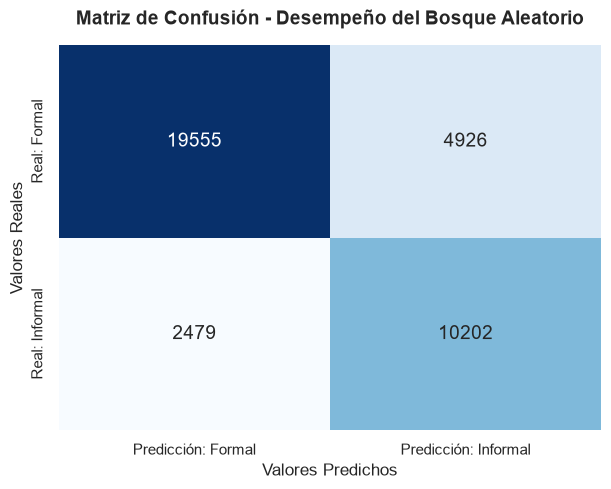

In [ ]:
# 1. Realizar predicciones sobre los datos nunca vistos
y_pred = modelo_rf.predict(X_test)

# 2. Imprimir el Reporte de Clasificación detallado

print(classification_report(y_test, y_pred, target_names=["Formal (0)", "Informal (1)"]))

# 3. Matriz de Confusión Estética
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            annot_kws={'size': 14},
            xticklabels=["Predicción: Formal", "Predicción: Informal"],
            yticklabels=["Real: Formal", "Real: Informal"])
plt.title("Matriz de Confusión - Desempeño del Bosque Aleatorio", pad=15, fontsize=14, fontweight='bold')
plt.ylabel('Valores Reales', fontsize=12)
plt.xlabel('Valores Predichos', fontsize=12)

# Guardar la imagen en alta resolución
plt.savefig("../Resultados/8_Matriz_Confusion_RF.png", dpi=300, bbox_inches='tight')
print(" Matriz de confusión guardada en: Resultados/8_Matriz_Confusion_RF.png")
plt.show()


### Análisis de la Curva ROC y Área Bajo la Curva (AUC)
La Curva ROC (Receiver Operating Characteristic) grafica la compensación entre la Tasa de Verdaderos Positivos y la Tasa de Falsos Positivos a distintos umbrales de probabilidad. El **AUC (Área Bajo la Curva)** resume el desempeño en un solo número (0.5 equivale a tirar una moneda, 1.0 es un modelo perfecto).


Curva ROC guardada en: Resultados/9_Curva_ROC_RF.png


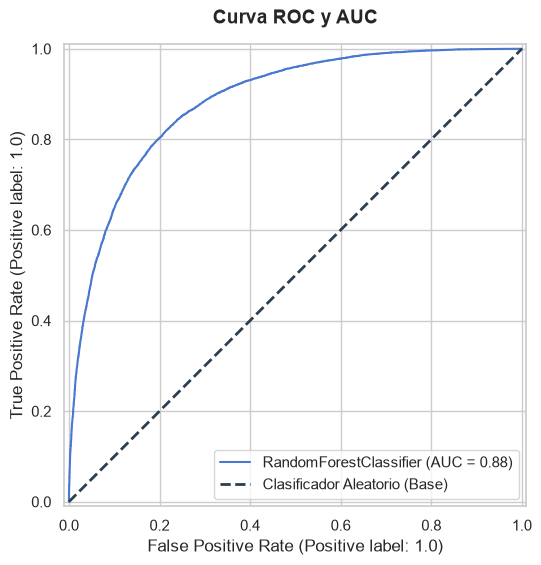

In [ ]:
# Generación de la Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))

# Nota: Si te marca error de 'color', tu versión de scikit-learn es antigua y debes quitar el argumento color de aquí
RocCurveDisplay.from_estimator(modelo_rf, X_test, y_test, ax=ax) 

plt.plot([0, 1], [0, 1], color='#2c3e50', linestyle='--', linewidth=2, label='Clasificador Aleatorio (Base)') 
plt.title("Curva ROC y AUC", pad=15, fontsize=14, fontweight='bold')
plt.legend(loc="lower right")

# Guardar la imagen en alta resolución
plt.savefig("../Resultados/9_Curva_ROC_RF.png", dpi=300, bbox_inches='tight')
print("Curva ROC guardada en: Resultados/9_Curva_ROC_RF.png")
plt.show()
